## Modeling

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
pitch_data = pd.read_csv("pitches.csv")

pitch_data.head(10)

,game_id,game_date,game_type,year,event_index,pitch_number,home_team,away_team,batter_id,bat_side,...,plate_time,gravity,plate_x_line,plate_z_line,plate_z_gravity,horz_break,vert_break,induced_vert_break,x0,z0
0,778564,2025-03-19,R,2025,30,6,CHC,LAD,500743,R,...,0.419191,-32.17,0.755842,5.666770,2.840301,-2.686527,-23.523912,10.393723,2.072902,5.881089
1,778564,2025-03-19,R,2025,30,5,CHC,LAD,500743,R,...,0.415995,-32.17,1.470153,4.464743,1.681201,0.552804,-21.225878,12.176627,2.266607,5.821112
2,778564,2025-03-19,R,2025,30,4,CHC,LAD,500743,R,...,0.481554,-32.17,1.938253,6.945237,3.215215,-13.234991,-47.560853,-2.800592,2.218523,6.114390
3,778564,2025-03-19,R,2025,30,3,CHC,LAD,500743,R,...,0.423077,-32.17,1.089655,4.516511,1.637386,-0.271802,-22.027027,12.522473,2.051341,5.868316
4,778564,2025-03-19,R,2025,30,2,CHC,LAD,500743,R,...,0.488141,-32.17,2.008279,8.186242,4.353487,-12.261962,-52.026425,-6.033357,2.169051,6.284653
5,778564,2025-03-19,R,2025,30,1,CHC,LAD,500743,R,...,0.477949,-32.17,1.431112,5.859514,2.185133,-13.053587,-45.521143,-1.428569,2.040922,6.048661
6,778564,2025-03-19,R,2025,29,5,CHC,LAD,624424,L,...,0.417907,-32.17,1.364657,4.953075,2.143897,-3.130880,-21.771125,11.939017,2.043909,5.847376
7,778564,2025-03-19,R,2025,29,4,CHC,LAD,624424,L,...,0.459009,-32.17,-0.134260,4.114364,0.725432,-14.233009,-40.082297,0.584893,1.637477,5.958204
8,778564,2025-03-19,R,2025,29,3,CHC,LAD,624424,L,...,0.459103,-32.17,-0.671251,4.461252,1.070931,-12.576381,-37.566447,3.117402,1.742112,5.872303
9,778564,2025-03-19,R,2025,29,2,CHC,LAD,624424,L,...,0.465998,-32.17,1.658761,5.753606,2.260687,-13.327983,-41.077908,0.837118,2.020727,5.995086


In [4]:
#### Organize pitch counts by pitcher + pitch type + get usage rate

#### Create dummy variables - runner on 1st, 2nd, 3rd, # of runners in scoring position, bases loaded

#### Wrangle it down to only include relevant info

pitchers = pitch_data[['pitcher_id', 'pitch_hand', 'outs', 'balls', 'strikes', 'pitch_type']]

pitcher_ids = pd.read_csv("pitcher_ids.csv")

pitcher_ids.head(5)


,player_id,name_full,name_last,name_first,name_given,name_middle,name_nickname,name_matrilineal,name_pronounce,birth_date,...,birth_country,draft_year,mlb_debut_date,bat_side,throw_hand,height,weight,sz_top,sz_bot,primary_position
0,671096,Andrew Abbott,Abbott,Andrew,Andrew,Cole,NaN,NaN,NaN,1999-06-01,...,USA,2021.0,2023-06-05,L,L,"6' 0""",192,3.370,1.540,1
1,690953,Mick Abel,Abel,Mick,McLean,Stine,NaN,NaN,AY-bull,2001-08-18,...,USA,2020.0,2025-05-18,R,R,"6' 5""",190,3.433,1.733,1
2,691769,Philip Abner,Abner,Philip,Philip,James,NaN,NaN,NaN,2002-05-05,...,USA,2023.0,2025-09-19,L,L,"6' 1""",230,3.410,1.570,1
3,682928,CJ Abrams,Abrams,CJ,Paul,Christopher,NaN,NaN,NaN,2000-10-03,...,USA,2019.0,2022-04-08,L,R,"6' 0""",191,3.223,1.626,6
4,650556,Bryan Abreu,Abreu,Bryan,Bryan,Enrique,NaN,Jimenez,NaN,1997-04-22,...,Dominican Republic,NaN,2019-07-31,R,R,"6' 1""",230,3.255,1.643,1


In [5]:
### Merging of Data sets


pitcher_ids = pitcher_ids.rename(columns = {"player_id": "pitcher_id"})

pitcher_ids = pitcher_ids[['pitcher_id', 'name_full']]

pitchers = pd.merge(pitchers, pitcher_ids, on = "pitcher_id", how = "inner")



In [6]:
pitchers.head(5)

,pitcher_id,pitch_hand,outs,balls,strikes,pitch_type,name_full
0,657006,L,2,3,2,FF,Justin Steele
1,657006,L,2,2,2,FF,Justin Steele
2,657006,L,2,2,1,SL,Justin Steele
3,657006,L,2,1,1,FF,Justin Steele
4,657006,L,2,0,1,SL,Justin Steele


In [7]:
### Pitch_counts

pitch_usage = (
    pitchers.dropna(subset=['pitch_type'])
            .groupby(['name_full', 'pitcher_id', 'pitch_type'])
            .size()
            .reset_index(name = 'pitch_count')
)

pitch_usage = (
    pitch_usage.assign(
        total_pitches = lambda x: x.groupby(['name_full', 'pitcher_id'])['pitch_count'].transform('sum'),
        pitch_pct = lambda x: (x['pitch_count']/x['total_pitches']) * 100
    )
)

pitch_usage.head(5)

,name_full,pitcher_id,pitch_type,pitch_count,total_pitches,pitch_pct
0,A.J. Minter,621345,CH,4,19,21.052632
1,A.J. Minter,621345,FC,5,19,26.315789
2,A.J. Minter,621345,FF,10,19,52.631579
3,A.J. Puk,640462,FF,29,43,67.441860
4,A.J. Puk,640462,SL,14,43,32.558140


In [8]:
wide_pitch = pitch_usage.pivot(
    index = ['name_full', 'pitcher_id'],
    columns = 'pitch_type',
    values = 'pitch_count'
).fillna(0).reset_index()

wide_pitch = wide_pitch.drop(columns=['UN'])

wide_pitch.head(5)

pitch_type,name_full,pitcher_id,CH,CS,CU,EP,FA,FC,FF,FO,FS,KC,KN,PO,SI,SL,ST,SV
0,A.J. Minter,621345,4.0,0.0,0.0,0.0,0.0,5.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A.J. Puk,640462,0.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0
2,AJ Smith-Shawver,700363,0.0,0.0,18.0,0.0,0.0,0.0,22.0,0.0,27.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0
3,Aaron Bummer,607481,0.0,0.0,3.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,15.0,0.0
4,Aaron Civale,650644,0.0,0.0,7.0,0.0,0.0,30.0,7.0,0.0,3.0,0.0,0.0,0.0,15.0,0.0,6.0,0.0


In [9]:
wide_pitch_pct = pitch_usage.pivot(
    index = ['name_full', 'pitcher_id'],
    columns = 'pitch_type',
    values = 'pitch_pct'
).fillna(0).reset_index()

wide_pitch_pct = wide_pitch_pct.drop(columns=['CS', 'EP', 'FA', 'PO', 'SV', 'UN'])

wide_pitch_pct = wide_pitch_pct.rename(columns=({"CH": "usage_CH", "CU": "usage_CU", "FC": "usage_FC", "FF": "usage_FF", "FO": "usage_FO",
                                                "FS": "usage_FS", "KC": "usage_KC", "KN": "usage_KN", "SI": "usage_SI", "SL": "usage_SL",
                                                "ST": "usage_ST"}))

wide_pitch_pct.head(5)

pitch_type,name_full,pitcher_id,usage_CH,usage_CU,usage_FC,usage_FF,usage_FO,usage_FS,usage_KC,usage_KN,usage_SI,usage_SL,usage_ST
0,A.J. Minter,621345,21.052632,0.000000,26.315789,52.631579,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,A.J. Puk,640462,0.000000,0.000000,0.000000,67.441860,0.0,0.000000,0.0,0.0,0.000000,32.558140,0.000000
2,AJ Smith-Shawver,700363,0.000000,23.376623,0.000000,28.571429,0.0,35.064935,0.0,0.0,0.000000,12.987013,0.000000
3,Aaron Bummer,607481,0.000000,8.823529,0.000000,11.764706,0.0,0.000000,0.0,0.0,35.294118,0.000000,44.117647
4,Aaron Civale,650644,0.000000,10.294118,44.117647,10.294118,0.0,4.411765,0.0,0.0,22.058824,0.000000,8.823529


In [10]:
#### Only select certain columns from the main data set
#### Join the new data set with the pitch usage table
#### Create dummy variables regarding players on 1st, 2nd, 3rd
#### Develop a regression model using such variables

full_data = pitch_data[['bat_side', 'pre_runner_1b_id'
                        ,'pre_runner_2b_id', 'pre_runner_3b_id',
                        'outs', 'balls', 'strikes', 'if_fielding_alignment',
                        'of_fielding_alignment', 'pitch_type', 'pitcher_id']]

full_data['runner_1B'] = np.where(full_data['pre_runner_1b_id'] > 1, 1, 0)
full_data['runner_2B'] = np.where(full_data['pre_runner_2b_id'] > 1, 1, 0)
full_data['runner_3B'] = np.where(full_data['pre_runner_3b_id'] > 1, 1, 0)




/var/folders/3y/gq6sf5yj2tbcs71pbsxtqf4m0000gn/T/ipykernel_50741/2338915225.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_data['runner_1B'] = np.where(full_data['pre_runner_1b_id'] > 1, 1, 0)
/var/folders/3y/gq6sf5yj2tbcs71pbsxtqf4m0000gn/T/ipykernel_50741/2338915225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_data['runner_2B'] = np.where(full_data['pre_runner_2b_id'] > 1, 1, 0)
/var/folders/3y/gq6sf5yj2tbcs71pbsxtqf4m0000gn/T/ipykernel_50741/2338915225.py:13: SettingWithCopyWarnin

In [11]:
full_data_1 = full_data

full_data = pd.merge(full_data, wide_pitch_pct, on = "pitcher_id", how = "inner")

In [12]:
full_data.head(5)

,bat_side,pre_runner_1b_id,pre_runner_2b_id,pre_runner_3b_id,outs,balls,strikes,if_fielding_alignment,of_fielding_alignment,pitch_type,...,usage_CU,usage_FC,usage_FF,usage_FO,usage_FS,usage_KC,usage_KN,usage_SI,usage_SL,usage_ST
0,R,NaN,NaN,NaN,2,3,2,Standard,Standard,FF,...,3.153153,0.0,54.054054,0.0,0.0,0.0,0.0,7.657658,32.432432,0.0
1,R,NaN,NaN,NaN,2,2,2,Standard,Standard,FF,...,3.153153,0.0,54.054054,0.0,0.0,0.0,0.0,7.657658,32.432432,0.0
2,R,NaN,NaN,NaN,2,2,1,Standard,Standard,SL,...,3.153153,0.0,54.054054,0.0,0.0,0.0,0.0,7.657658,32.432432,0.0
3,R,NaN,NaN,NaN,2,1,1,Standard,Standard,FF,...,3.153153,0.0,54.054054,0.0,0.0,0.0,0.0,7.657658,32.432432,0.0
4,R,NaN,NaN,NaN,2,0,1,Standard,Standard,SL,...,3.153153,0.0,54.054054,0.0,0.0,0.0,0.0,7.657658,32.432432,0.0


In [13]:
full_dummies = pd.get_dummies(full_data[['bat_side', 'if_fielding_alignment', 'of_fielding_alignment']], drop_first=True).astype(int)


full_data = pd.concat([full_data, full_dummies], axis=1)
full_data.head(5)

,bat_side,pre_runner_1b_id,pre_runner_2b_id,pre_runner_3b_id,outs,balls,strikes,if_fielding_alignment,of_fielding_alignment,pitch_type,...,usage_FS,usage_KC,usage_KN,usage_SI,usage_SL,usage_ST,bat_side_R,if_fielding_alignment_Standard,if_fielding_alignment_Strategic,of_fielding_alignment_Strategic
0,R,NaN,NaN,NaN,2,3,2,Standard,Standard,FF,...,0.0,0.0,0.0,7.657658,32.432432,0.0,1,1,0,0
1,R,NaN,NaN,NaN,2,2,2,Standard,Standard,FF,...,0.0,0.0,0.0,7.657658,32.432432,0.0,1,1,0,0
2,R,NaN,NaN,NaN,2,2,1,Standard,Standard,SL,...,0.0,0.0,0.0,7.657658,32.432432,0.0,1,1,0,0
3,R,NaN,NaN,NaN,2,1,1,Standard,Standard,FF,...,0.0,0.0,0.0,7.657658,32.432432,0.0,1,1,0,0
4,R,NaN,NaN,NaN,2,0,1,Standard,Standard,SL,...,0.0,0.0,0.0,7.657658,32.432432,0.0,1,1,0,0


In [14]:
full_data.columns

Index(['bat_side', 'pre_runner_1b_id', 'pre_runner_2b_id', 'pre_runner_3b_id',
       'outs', 'balls', 'strikes', 'if_fielding_alignment',
       'of_fielding_alignment', 'pitch_type', 'pitcher_id', 'runner_1B',
       'runner_2B', 'runner_3B', 'name_full', 'usage_CH', 'usage_CU',
       'usage_FC', 'usage_FF', 'usage_FO', 'usage_FS', 'usage_KC', 'usage_KN',
       'usage_SI', 'usage_SL', 'usage_ST', 'bat_side_R',
       'if_fielding_alignment_Standard', 'if_fielding_alignment_Strategic',
       'of_fielding_alignment_Strategic'],
      dtype='object')

In [15]:
full_data = full_data.dropna(subset=['pitch_type'])

In [16]:
### Build regression model
le = LabelEncoder()

X = full_data[['runner_1B', 'runner_2B', 'runner_3B', 'usage_CH',
               'usage_CU', 'usage_FC', 'usage_FF', 'usage_FO',
               'usage_FS', 'usage_KC', 'usage_KN', 'usage_SI', 
               'usage_SL', 'usage_ST', 'bat_side_R',
               'if_fielding_alignment_Standard', 'if_fielding_alignment_Strategic',
               'of_fielding_alignment_Strategic']]
y = le.fit_transform(full_data['pitch_type'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=334)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [17]:
model = LogisticRegression(
    solver = 'lbfgs',
    max_iter = 1000
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
pitch_predictions = model.predict(X_test)

pitch_pred_labels = le.inverse_transform(pitch_predictions)
pitch_test_labels = le.inverse_transform(y_test)

##print(classification_report(pitch_test_labels, pitch_pred_labels))


In [19]:
print(full_data['pitch_type'].dtype)
print(full_data['pitch_type'].unique())
print(full_data['pitch_type'].isna().sum())

object
['FF' 'SL' 'ST' 'FS' 'SI' 'CH' 'KC' 'CU' 'FC' 'SV' 'FA' 'FO' 'PO' 'EP'
 'KN' 'CS' 'UN']
0


In [20]:
print(classification_report(pitch_test_labels, pitch_pred_labels))

              precision    recall  f1-score   support

          CH       0.43      0.23      0.30       509
          CS       0.00      0.00      0.00         2
          CU       0.26      0.20      0.23       226
          EP       0.43      0.75      0.55         4
          FA       0.78      0.70      0.74        10
          FC       0.44      0.42      0.43       368
          FF       0.46      0.60      0.52      1503
          FO       0.25      0.50      0.33         2
          FS       0.32      0.24      0.28       199
          KC       0.41      0.36      0.38        67
          SI       0.44      0.47      0.46       722
          SL       0.45      0.36      0.40       690
          ST       0.34      0.34      0.34       342
          SV       0.31      0.25      0.28        36
          UN       0.00      0.00      0.00         1

    accuracy                           0.43      4681
   macro avg       0.35      0.36      0.35      4681
weighted avg       0.42   

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

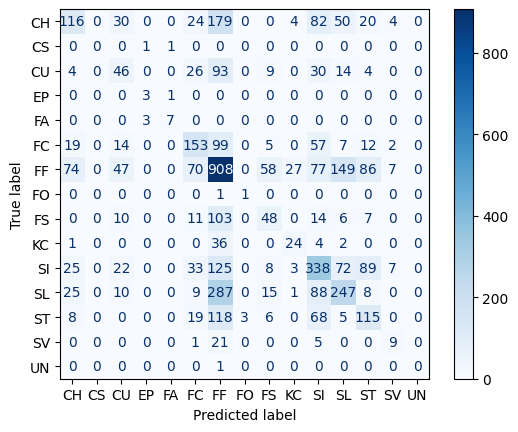

In [21]:
## Confusion Matrix

present_labels = list(le.classes_[np.isin(le.classes_, np.unique(pitch_test_labels))])

cm = confusion_matrix(pitch_test_labels, pitch_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_labels)
disp.plot(cmap = 'Blues')
plt.show()

In [22]:
### Important Features

feature_cols = ['runner_1B', 'runner_2B', 'runner_3B', 'usage_CH',
                'usage_CU', 'usage_FC', 'usage_FF', 'usage_FO',
                'usage_FS', 'usage_KC', 'usage_KN', 'usage_SI', 
                'usage_SL', 'usage_ST', 'bat_side_R',
                'if_fielding_alignment_Standard', 'if_fielding_alignment_Strategic',
                'of_fielding_alignment_Strategic']

coefficients = pd.DataFrame(
    model.coef_,
    index = model.classes_,
    columns = feature_cols
)
print(coefficients)


    runner_1B  runner_2B  runner_3B  usage_CH  usage_CU  usage_FC  usage_FF  \
0   -0.103869   0.042230   0.085448  1.293011  0.435104  0.182926  0.368066   
1    0.520928  -0.376721  -0.246719  0.654113  0.846644  0.250805  0.142341   
2   -0.191089   0.040831   0.100337  0.800034  1.569679  0.774459  1.077554   
3   -0.676723  -0.379315  -0.215743 -1.318986 -0.751928 -1.729545 -3.098518   
4    0.056354   0.303863   0.187415 -1.957122 -0.972748 -1.939934 -2.684089   
5   -0.088206   0.003412   0.087451  0.429238  0.369230  1.134961  0.405297   
6   -0.161779  -0.017225   0.118802  0.445270  0.372308  0.140417  1.041321   
7    0.094722   0.434371  -0.016543  0.045394  0.050459 -0.038796 -0.014050   
8   -0.123179   0.032670   0.119060 -1.725987  0.333257  0.311703  0.613680   
9   -0.142028  -0.007814   0.185614  0.593506 -2.318535  0.257130  0.629336   
10   0.522602  -0.187058  -0.331431  0.048430  0.050132 -0.050238 -0.014324   
11   0.826736  -0.293256  -0.191593 -0.154612 -0.371

In [23]:
print("\nMost influential features overall:")
print(coefficients.abs().mean().sort_values(ascending=False))


Most influential features overall:
usage_SI                           0.915473
usage_FF                           0.891864
usage_CH                           0.805980
usage_ST                           0.761735
usage_SL                           0.740720
usage_CU                           0.705811
usage_FC                           0.589121
usage_FS                           0.524429
usage_KC                           0.450557
if_fielding_alignment_Standard     0.275831
runner_1B                          0.252668
bat_side_R                         0.211569
runner_2B                          0.157674
usage_FO                           0.148624
runner_3B                          0.139369
usage_KN                           0.116072
if_fielding_alignment_Strategic    0.108659
of_fielding_alignment_Strategic    0.082488
dtype: float64


In [24]:
print("help me")

help me
